# <center>Comparaison of `Linear Regression`, `Ridge Regression` and `Elastic Net` <center>
     
###  <center>Data-Driven and Optimization<center>    

# Import all packages 

In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Load the data

In [2]:
df = pd.read_csv("/home/leonard/Documents/Data-Driven/LifeExpectancyData.csv")

## Visualize the data

In [3]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.shape

(2938, 22)

In [5]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [6]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

We are seen from this information that `status` only is a categorical variable and the remainder is numerical.

## Data preprocessing

In [8]:
# Drop 'Country' (not useful for regression)
df.drop(columns=["Country"], inplace=True)  

Replace the NaN value by the mean for the numerical variable

In [9]:

# Select numerical variables, excluding "Status"
numerical_variables = df.columns[df.columns != "Status"]

# Calculate the median for each numerical variable
medians = df[numerical_variables].mean()

# Fill missing values with the median for each numerical variable
df[numerical_variables] = df[numerical_variables].fillna(medians)
        
    

In [10]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [11]:
df.isnull().sum()

Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [12]:
df["Status"].unique()

array(['Developing', 'Developed'], dtype=object)

## Encoding the categorical variable

Encoding the categorical variable using `LabelEncoder` which is a class from the `sklearn.preprocessing` module that converts categorical labels into numerical values. Each unique category in the column is assigned an integer value. 

In [13]:
# Encode 'Status'
df["Status"] = LabelEncoder().fit_transform(df["Status"]) 

In [14]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [15]:
df["Status"].unique()

array([1, 0])

## Create a `features` and `target` from the data

In [16]:
# Separate features and target variable
X = df.drop(columns=["Life expectancy "])  # Features
y = df["Life expectancy "]  # Target

In [17]:
X.head()

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Standardize the data

In [18]:
# Identify numerical features (excluding "Status")
numerical_features = [col for col in X.columns if col != "Status"]

# Apply StandardScaler only to numerical columns
scaler = StandardScaler()
X_scaled = X.copy()  # Preserve DataFrame structure
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

In [19]:
X_scaled.head()

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1.621762,1,0.791586,0.268824,-1.172958,-0.335570,-0.705861,-0.110384,-0.964715,0.255359,-3.278638,0.925806,-0.732952,-0.323445,-0.525248,0.389975,2.813130,2.773279,-0.725401,-0.579931
1,1.404986,1,0.856072,0.285786,-1.172958,-0.334441,-0.838704,-0.168124,-0.989810,0.274060,-1.051482,0.934140,-0.859877,-0.323445,-0.523083,-0.230936,2.881408,2.817902,-0.740050,-0.610570
2,1.188210,1,0.831890,0.302749,-1.172958,-0.334594,-0.750142,-0.173531,-1.014905,0.292761,-0.880163,0.913306,-0.775260,-0.323445,-0.521632,0.352715,2.926927,2.862526,-0.769349,-0.641209
3,0.971434,1,0.864132,0.328193,-1.172958,-0.332096,-0.617299,0.032045,-1.040000,0.317696,-0.666013,1.075815,-0.648335,-0.323445,-0.518723,-0.168315,2.972446,2.929461,-0.803531,-0.671847
4,0.754658,1,0.888314,0.345155,-1.172958,-0.367862,-0.573018,0.051757,-1.060076,0.342631,-0.623183,0.804966,-0.606027,-0.323445,-0.564893,-0.181666,3.040724,2.974085,-0.847480,-0.763764


## Split the data to $80\%$ training  and $20\%$ testing

In [20]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Create a polynomial features to perform the model.

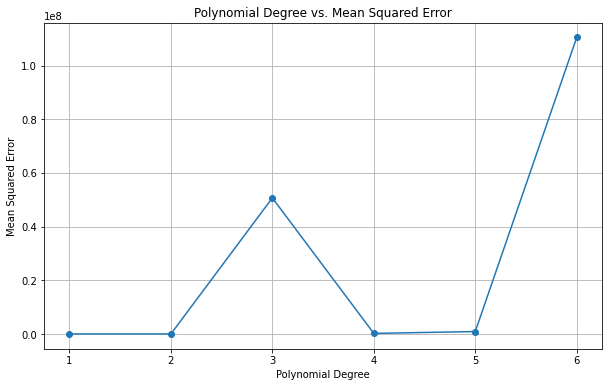

The optimal polynomial degree is: 2


In [23]:
# Initialize variables to store results
degrees = range(1, 7)  # Test polynomial degrees from 1 to 17
mse_scores = []

# Loop over different polynomial degrees
for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    
    # Train the model
    model = LinearRegression()
    
    # Use cross-validation to evaluate the model
    mse = -cross_val_score(model, X_train_poly, y_train, cv=3, scoring='neg_mean_squared_error')
    
    # Store the mean MSE score
    mse_scores.append(np.mean(mse))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_scores, marker='o')
plt.title('Polynomial Degree vs. Mean Squared Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.xticks(degrees)
plt.grid()
plt.show()

# Print the degree with the lowest MSE
best_degree = degrees[np.argmin(mse_scores)]
print(f"The optimal polynomial degree is: {best_degree}")

In [24]:
#applying polynomial regression degree 2
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(X_train)
x_test_trans = poly.transform(X_test)

# Train the model

## Model 1 : Linear regression 

In [25]:
#include bias parameter
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred_lr = lr.predict(x_test_trans)
mse_lr    = mean_squared_error(y_test, y_pred_lr)
r2_lr     = r2_score(y_test, y_pred_lr)

print("*"*17)
print("LINEAR REGRESSION")
print("*"*17)
print(f"Mean Squared Error :  {mse_lr}")
print(f"R²- score :  {r2_lr}")

*****************
LINEAR REGRESSION
*****************
Mean Squared Error :  8.012064751485605
R²- score :  0.9075196035900236


## Model 2 : Ridge Regrssion

In [26]:
#  Tune Ridge Regression (using GridSearchCV)
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_reg = GridSearchCV(Ridge(), ridge_params, scoring="r2", cv=5)
ridge_reg.fit(x_train_trans, y_train)
best_ridge = ridge_reg.best_estimator_
y_pred_ridge = best_ridge.predict(x_test_trans)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [27]:
print("*"*17)
print("RIDGE REGRESSION")
print("*"*17)
print(f"Mean Squared Error :  {mse_ridge}")
print(f"Best alpha :  {best_ridge}")
print(f"R² score :  {r2_ridge}")

*****************
RIDGE REGRESSION
*****************
Mean Squared Error :  7.259763184721878
Best alpha :  Ridge(alpha=100)
R² score :  0.9162031513735404


## Model 3 : Elastic Net 

In [28]:
import warnings
warnings.filterwarnings("ignore")
#  Tune Elastic Net (using GridSearchCV)
elastic_params = {"alpha": [0.01, 0.1, 1, 10, 100], "l1_ratio": [0.1, 0.5, 0.9]}
elastic_net = GridSearchCV(ElasticNet(), elastic_params, scoring="r2", cv=5)
elastic_net.fit(x_train_trans, y_train)
best_elastic = elastic_net.best_estimator_
y_pred_elastic = best_elastic.predict(x_test_trans)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)


print("*"*17)
print("ELASTIC NET")
print("*"*17)
print(f"Mean Squared Error :  {mse_elastic}")
print(f"Best L1 ratio :  {best_elastic.l1_ratio}, best L2 ratio : {best_elastic.alpha}")
print(f"R² score :  {r2_elastic}")



*****************
ELASTIC NET
*****************
Mean Squared Error :  6.974798682851749
Best L1 ratio :  0.9, best L2 ratio : 0.01
R² score :  0.9194923946476707


## Comparaison of the three models

In [29]:
# Create a DataFrame to compare the models
resume_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Elastic Net'],
    'Mean Square Error': [mse_lr, mse_ridge, mse_elastic],
    'R² score': [r2_lr, r2_ridge, r2_elastic]
})
resume_df

,Model,Mean Square Error,R² score
0,Linear Regression,8.012065,0.907520
1,Ridge Regression,7.259763,0.916203
2,Elastic Net,6.974799,0.919492


### Metrics Overview
- Mean Square Error (MSE):

    - MSE measures the average squared difference between predicted and actual values. A lower MSE indicates better model performance, as it means the predictions are closer to the actual values.

- R² Score:

    - R² indicates the proportion of variance in the dependent variable that is predictable from the independent variables. R² values range from 0 to 1, with higher values indicating better model performance. An R² of 1 means the model perfectly predicts the target variable.

From the table above, by using these two metrics, we have : 
- `Elastic Net` outperforms both `Ridge Regression` and `Linear Regression` in terms of both MSE and R² score, indicating it provides the most accurate predictions and explains the most variance.
- `Ridge Regression` performs better than `Linear Regression`, suggesting that the regularization effect helps improve model performance by reducing overfitting.
- `Linear Regression` has the highest MSE and the lowest R² score, indicating it is the least effective model among the three.

Overall, the results suggest that using regularization techniques (Ridge and Elastic Net) leads to improved model performance compared to standard Linear Regression. Elastic Net, combining both L1 and L2 regularization, is particularly effective in this scenario, likely enhancing the model's ability to generalize well to unseen data.